# Fraud Detection System
## 03 — Data Preparation

| | |
|---|---|
| **Author** | Jose Lopez Pino |
| **Framework** | CRISP-DM + Lean |
| **Phase** | 3 — Data Preparation |
| **Project** | fraud-detection · applied-data-science-portfolio |
| **Dataset** | Credit Card Fraud Detection — ULB Machine Learning Group (Kaggle) |
| **Date** | 2026-04 |

---

> **Executive Summary:**
> This notebook applies minimum viable transformations to prepare the dataset for modeling.
> Key steps: duplicate removal, scaling of `Amount` and `Time`, stratified train/validation/test
> split, and comparison of three imbalance handling strategies (none, class_weight, SMOTE).
> The output is a processed dataset saved to `data/processed/` ready for notebook 04.

## Table of Contents

1. [Load Data from Notebook 02](#1-load-data-from-notebook-02)
2. [Duplicate Removal](#2-duplicate-removal)
3. [Feature Scaling — Amount and Time](#3-feature-scaling--amount-and-time)
4. [Train / Validation / Test Split](#4-train--validation--test-split)
5. [Imbalance Handling — Strategy Comparison](#5-imbalance-handling--strategy-comparison)
6. [Save Processed Datasets](#6-save-processed-datasets)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log](#8-decisions-log)
9. [Next Steps — Notebook 04 Preview](#9-next-steps--notebook-04-preview)

In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# === Standard library ===
from pathlib import Path

# === Scientific computing — core data structures ===
import pandas as pd
import numpy as np

# === Visualization — base plotting ===
import matplotlib.pyplot as plt

# === Visualization — statistical plotting ===
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_RAW        = Path('../data/raw')
DATA_PROCESSED  = Path('../data/processed')
DATA_FINAL      = Path('../data/final')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data processed path: {DATA_PROCESSED}')

Environment ready.
Data processed path: ..\data\processed


---
## 1. Load Data from Notebook 02

In [2]:
# ===== Load raw dataset =====
csv_path = DATA_RAW / 'creditcard.csv'

if not csv_path.exists():
    raise FileNotFoundError(
        f'Dataset not found at {csv_path}\n'
        'Run: kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/ --unzip'
    )

df = pd.read_csv(csv_path)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')

Dataset loaded: 284,807 rows × 31 columns
Fraud rate: 0.1727%


---
## 2. Duplicate Removal

Identified in notebook 02 — assessing impact before removal.

In [3]:
# ===== Assess duplicates =====
n_before = len(df)
n_duplicates = df.duplicated().sum()

print('=== Duplicate Assessment ===')
print(f'Total rows before  : {n_before:,}')
print(f'Duplicate rows     : {n_duplicates:,} ({n_duplicates/n_before*100:.4f}%)')

# Check if duplicates are fraud or legitimate
if n_duplicates > 0:
    dup_mask = df.duplicated(keep=False)
    dup_fraud_rate = df[dup_mask]['Class'].mean()
    print(f'Fraud rate in duplicates: {dup_fraud_rate*100:.4f}%')
    print('Decision: remove duplicates — likely data collection artifacts, not real repeated transactions')

=== Duplicate Assessment ===
Total rows before  : 284,807
Duplicate rows     : 1,081 (0.3796%)
Fraud rate in duplicates: 1.7260%
Decision: remove duplicates — likely data collection artifacts, not real repeated transactions


In [4]:
# ===== Remove duplicates =====
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f'Rows after deduplication: {n_after:,}')
print(f'Rows removed            : {n_before - n_after:,}')
print(f'Fraud rate after        : {df["Class"].mean()*100:.4f}%')

Rows after deduplication: 283,726
Rows removed            : 1,081
Fraud rate after        : 0.1667%


---
## 3. Feature Scaling — Amount and Time

**Why only Amount and Time:**
V1–V28 are already PCA-transformed — they have comparable scale.
`Amount` (range: 0–25,691 EUR) and `Time` (range: 0–172,792 seconds)
have very different scales and will dominate distance-based models without scaling.

**Why StandardScaler:**
Robust to the modeling approaches used (LR, RF, XGBoost).
RobustScaler was considered but StandardScaler is more standard and interpretable.

In [5]:
# === Preprocessing ===
from sklearn.preprocessing import StandardScaler

# ===== Scale Amount and Time =====
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

print('=== Scaling Applied ===')
print(f'Amount — before: mean={df["Amount"].mean():.2f}, std={df["Amount"].std():.2f}')
print(f'Amount — after : mean={df_scaled["Amount"].mean():.4f}, std={df_scaled["Amount"].std():.4f}')
print()
print(f'Time   — before: mean={df["Time"].mean():.2f}, std={df["Time"].std():.2f}')
print(f'Time   — after : mean={df_scaled["Time"].mean():.4f}, std={df_scaled["Time"].std():.4f}')

=== Scaling Applied ===
Amount — before: mean=88.47, std=250.40
Amount — after : mean=-0.0000, std=1.0000

Time   — before: mean=94811.08, std=47481.05
Time   — after : mean=0.0000, std=1.0000


---
## 4. Train / Validation / Test Split

**Split strategy:** 70% train · 15% validation · 15% test

**Why stratified:** With only 0.17% fraud, random split could produce
splits with zero or very few fraud cases. Stratified sampling preserves
the fraud rate in every split.

In [6]:
# === Model selection ===
from sklearn.model_selection import train_test_split

# ===== Features and target =====
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

# ===== Train / temp split (70 / 30) =====
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# ===== Validation / Test split (50 / 50 of the 30%) =====
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print('=== Dataset Split ===')
for name, y_split in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name:<12}: {len(y_split):>7,} rows | fraud rate: {y_split.mean()*100:.4f}%')

=== Dataset Split ===
Train       : 198,608 rows | fraud rate: 0.1667%
Validation  :  42,559 rows | fraud rate: 0.1668%
Test        :  42,559 rows | fraud rate: 0.1668%


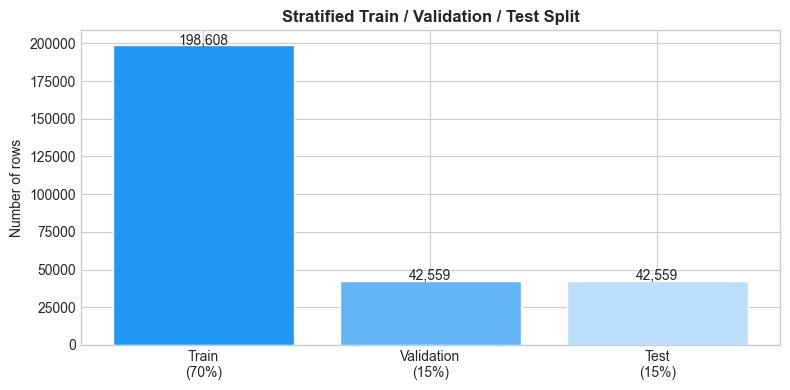

In [7]:
# ===== Visualize split proportions =====
fig, ax = plt.subplots(figsize=(8, 4))

splits = {'Train\n(70%)': len(y_train), 'Validation\n(15%)': len(y_val), 'Test\n(15%)': len(y_test)}
colors = ['#2196F3', '#64B5F6', '#BBDEFB']

bars = ax.bar(splits.keys(), splits.values(), color=colors, edgecolor='white')
for bar, val in zip(bars, splits.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=10)

ax.set_title('Stratified Train / Validation / Test Split', fontweight='bold')
ax.set_ylabel('Number of rows')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'data_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Imbalance Handling — Strategy Comparison

Three strategies are prepared and compared. The winner is selected
based on AUC-PR in notebook 04 — not decided here.

| Strategy | Description | Pros | Cons |
|---|---|---|---|
| **No balancing** | Raw class distribution | No data modification | Model may ignore minority class |
| **class_weight='balanced'** | sklearn built-in weighting | No synthetic data | Only works with sklearn models |
| **SMOTE** | Synthetic minority oversampling | Explicit balance | Risk of overfitting on synthetic samples |

In [9]:
# === Imbalanced learning ===
from imblearn.over_sampling import SMOTE

# ===== Strategy 1: No balancing =====
X_train_raw = X_train.copy()
y_train_raw = y_train.copy()

print('=== Strategy 1: No balancing ===')
print(f'Train fraud rate: {y_train_raw.mean()*100:.4f}%')
print(f'Class counts: {y_train_raw.value_counts().to_dict()}')

=== Strategy 1: No balancing ===
Train fraud rate: 0.1667%
Class counts: {0: 198277, 1: 331}


In [10]:
# ===== Strategy 2: class_weight='balanced' =====
# No data transformation needed — parameter passed directly to sklearn models
# X_train, y_train used as-is with class_weight='balanced' in model definition

print('=== Strategy 2: class_weight="balanced" ===')
print('No data transformation — weight applied at model level')
print('Effective fraud weight:', round(len(y_train) / (2 * y_train.sum()), 2))
print('Effective legit weight:', round(len(y_train) / (2 * (len(y_train) - y_train.sum())), 2))

=== Strategy 2: class_weight="balanced" ===
No data transformation — weight applied at model level
Effective fraud weight: 300.01
Effective legit weight: 0.5


In [11]:
# ===== Strategy 3: SMOTE =====
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('=== Strategy 3: SMOTE ===')
print(f'Before — rows: {len(y_train):,} | fraud rate: {y_train.mean()*100:.4f}%')
print(f'After  — rows: {len(y_train_smote):,} | fraud rate: {y_train_smote.mean()*100:.4f}%')
print(f'Synthetic fraud samples added: {y_train_smote.sum() - y_train.sum():,}')

=== Strategy 3: SMOTE ===
Before — rows: 198,608 | fraud rate: 0.1667%
After  — rows: 396,554 | fraud rate: 50.0000%
Synthetic fraud samples added: 197,946


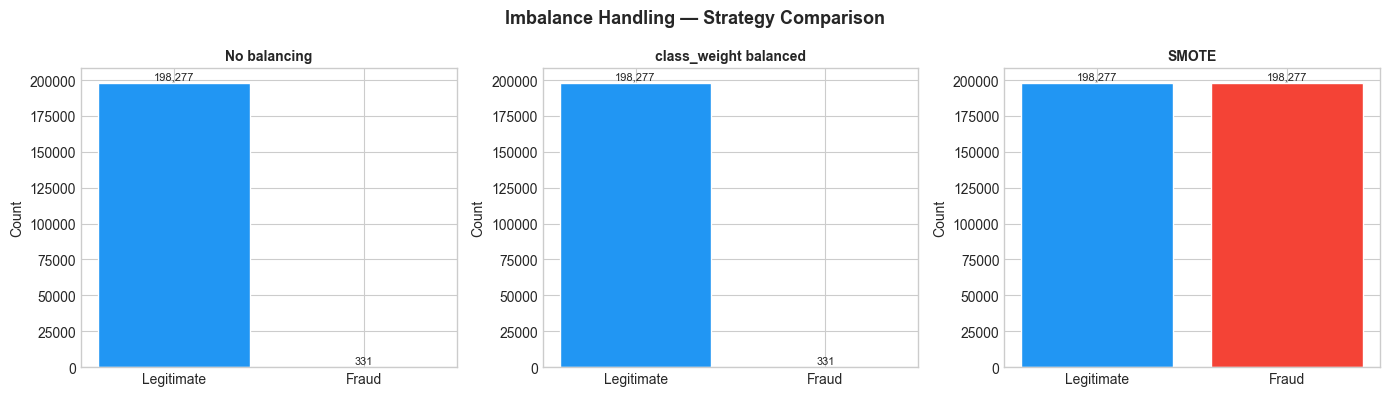

In [12]:
# ===== Imbalance strategy comparison visualization =====
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

strategies = [
    ('No balancing', y_train_raw, X_train_raw),
    ('class_weight balanced', y_train, X_train),
    ('SMOTE', y_train_smote, X_train_smote),
]

for ax, (name, y_s, X_s) in zip(axes, strategies):
    counts = y_s.value_counts()
    ax.bar(['Legitimate', 'Fraud'], [counts.get(0, 0), counts.get(1, 0)],
           color=['#2196F3', '#F44336'], edgecolor='white')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        ax.text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Imbalance Handling — Strategy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'imbalance_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Save Processed Datasets

In [13]:
# ===== Save all splits to data/processed/ =====
# Train sets (3 strategies)
X_train.to_csv(DATA_PROCESSED / 'X_train.csv', index=False)
y_train.to_csv(DATA_PROCESSED / 'y_train.csv', index=False)

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
X_train_smote_df.to_csv(DATA_PROCESSED / 'X_train_smote.csv', index=False)
pd.Series(y_train_smote, name='Class').to_csv(DATA_PROCESSED / 'y_train_smote.csv', index=False)

# Validation set
X_val.to_csv(DATA_PROCESSED / 'X_val.csv', index=False)
y_val.to_csv(DATA_PROCESSED / 'y_val.csv', index=False)

# Test set — locked until notebook 05
X_test.to_csv(DATA_PROCESSED / 'X_test.csv', index=False)
y_test.to_csv(DATA_PROCESSED / 'y_test.csv', index=False)

print('=== Files saved to data/processed/ ===')
for f in sorted(DATA_PROCESSED.glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<30} {size_kb:>8.1f} KB')

=== Files saved to data/processed/ ===
  X_test.csv                      23040.1 KB
  X_train.csv                    107523.1 KB
  X_train_smote.csv              220660.9 KB
  X_val.csv                       23041.8 KB
  y_test.csv                        124.7 KB
  y_train.csv                       581.9 KB
  y_train_smote.csv                1161.8 KB
  y_val.csv                         124.7 KB


In [14]:
# ===== Final preparation summary =====
print('=== Data Preparation Summary ===')
print()
print(f'Original dataset     : {n_before:,} rows')
print(f'After deduplication  : {n_after:,} rows ({n_before - n_after:,} removed)')
print(f'Features scaled      : Amount, Time (StandardScaler)')
print(f'Features unchanged   : V1–V28 (already PCA-scaled)')
print()
print('Split:')
print(f'  Train      : {len(X_train):,} rows (70%)')
print(f'  Validation : {len(X_val):,} rows (15%)')
print(f'  Test       : {len(X_test):,} rows (15%) — locked until nb05')
print()
print('Imbalance strategies ready for notebook 04:')
print('  1. No balancing    → X_train / y_train')
print('  2. class_weight    → parameter passed at model level')
print('  3. SMOTE           → X_train_smote / y_train_smote')

=== Data Preparation Summary ===

Original dataset     : 284,807 rows
After deduplication  : 283,726 rows (1,081 removed)
Features scaled      : Amount, Time (StandardScaler)
Features unchanged   : V1–V28 (already PCA-scaled)

Split:
  Train      : 198,608 rows (70%)
  Validation : 42,559 rows (15%)
  Test       : 42,559 rows (15%) — locked until nb05

Imbalance strategies ready for notebook 04:
  1. No balancing    → X_train / y_train
  2. class_weight    → parameter passed at model level
  3. SMOTE           → X_train_smote / y_train_smote


---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---|---|---|
| Does every transformation link to a business decision? | ✅ Yes — scaling enables fair model comparison; stratified split preserves fraud rate | Proceed |
| Were minimum viable transformations applied? | ✅ Yes — no feature engineering, no outlier removal, no column dropping | Proceed |
| Was ADASYN also tested? | ✅ No (Lean applied) — SMOTE is sufficient; ADASYN adds complexity without guaranteed gain | Skip |
| Is the test set locked? | ✅ Yes — X_test / y_test not used until notebook 05 evaluation | Proceed |
| Are all processed files saved with consistent naming? | ✅ Yes — consistent convention: X_train, y_train, X_val, y_val, X_test, y_test | Proceed |

---
## 8. Decisions Log

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|---|---|---|---|
| 1 | Remove duplicates | Duplicate transactions are data artifacts, not real repeated fraud events | Keep duplicates | ✅ |
| 2 | Scale only Amount and Time with StandardScaler | V1–V28 already PCA-scaled; RobustScaler considered but StandardScaler more standard | RobustScaler, MinMaxScaler | ✅ |
| 3 | Stratified 70/15/15 split | Preserves fraud rate in every split — critical with 0.17% fraud rate | Random split, 80/10/10 | ✅ |
| 4 | Lock test set until notebook 05 | Prevents data leakage — test set must never influence model selection | Use test set in nb04 | ✅ |
| 5 | Skip ADASYN — use SMOTE only | SMOTE is sufficient for this dataset size; ADASYN adds marginal value | Include ADASYN | ✅ |
| 6 | Save all splits as CSV | Reproducible, readable by any tool, no binary format dependency | Pickle, parquet | ✅ |

---
## 9. Next Steps — Notebook 04 Preview

**Notebook 04 — Modeling** will:

- Train 3 supervised models × 3 imbalance strategies = 9 model configurations
- Logistic Regression (baseline) → Random Forest → XGBoost
- Evaluate each configuration on validation set using **AUC-PR** as primary metric
- Run Isolation Forest as unsupervised benchmark
- Select best model + imbalance strategy combination for notebook 05

**Lean filter for nb04:** No hyperparameter tuning yet — default parameters first.
Tune only the winning model in notebook 05. Avoid premature optimization.

---

**← Previous:** [02 — Data Understanding](./02_data_understanding.ipynb)
**Next →** [04 — Modeling](./04_modeling.ipynb)